/usr/local/lib/python3.10/dist-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['Unnamed: 32']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


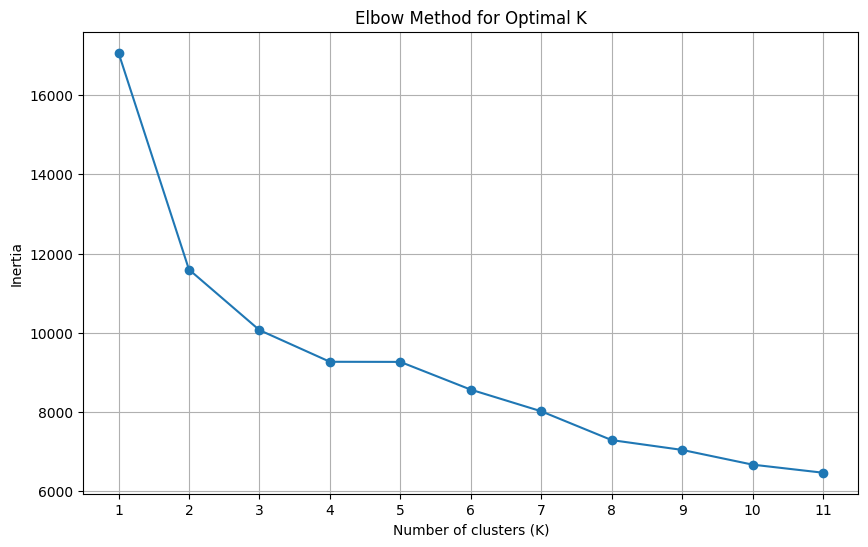

In [6]:

import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from matplotlib import pyplot as plt

# Load the data
data = pd.read_csv(r'/content/breast_cancer.csv')  # Replace with your actual file path

# Drop unnecessary columns
x = data.drop(['diagnosis', 'id'], axis=1)

# Handle missing values using imputation
imputer = SimpleImputer(strategy='mean')  # Replace with 'median' or 'most_frequent' if needed
x = imputer.fit_transform(x)

# Scale the data
scaler = StandardScaler()
x_scale = scaler.fit_transform(x)

# Determine optimal K using elbow method
K_range = range(1, 12)
inertia = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scale)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid()
plt.show()

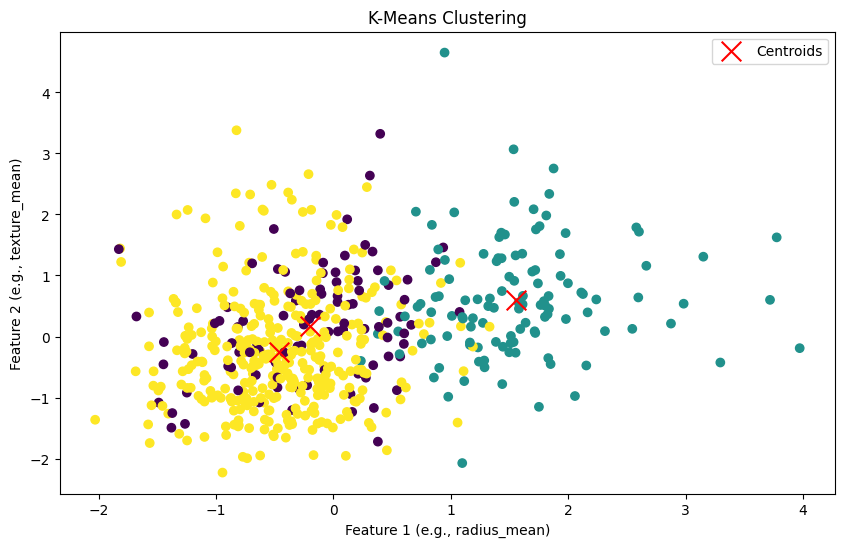

In [10]:
# prompt: give me the code for visualize the clusters and mark the centroid

# Assuming you have already determined the optimal K (e.g., K=3)
kmeans = KMeans(n_clusters=3, random_state=42)  # Replace 3 with your optimal K
kmeans.fit(x_scale)

# Get cluster labels and centroids
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Visualize the clusters (assuming you have 2 main features to plot)
plt.figure(figsize=(10, 6))

# Assuming 'radius_mean' and 'texture_mean' are your main features for visualization
plt.scatter(x_scale[:, 0], x_scale[:, 1], c=labels, cmap='viridis')  # Replace with your feature indices
plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=200, c='red', label='Centroids')
plt.xlabel('Feature 1 (e.g., radius_mean)')  # Replace with your feature names
plt.ylabel('Feature 2 (e.g., texture_mean)')
plt.title('K-Means Clustering')
plt.legend()
plt.show()


In [7]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x_scaled, data['diagnosis'], test_size=0.2, random_state=42)

# Create and fit the KMeans model
model = KMeans(n_clusters=3, random_state=42)
model.fit(x_train)

KMeans(n_clusters=3, random_state=42)

In [8]:
# prompt: give me the input prompt for accepting user input and predicting new data instance cluster

# Get user input for new data instance
new_data = []
for feature in data.columns.drop(['diagnosis', 'id']):
    value = input(f"Enter value for {feature}: ")
    new_data.append(float(value))

# Convert input to DataFrame
new_data_df = pd.DataFrame([new_data], columns=data.columns.drop(['diagnosis', 'id']))

# Preprocess new data (impute and scale)
new_data_imputed = imputer.transform(new_data_df)
new_data_scaled = scaler.transform(new_data_imputed)

# Predict the cluster for the new data instance
predicted_cluster = model.predict(new_data_scaled)[0]

print(f"The new data instance belongs to cluster {predicted_cluster}")

Enter value for radius_mean: 4
Enter value for texture_mean: 5
Enter value for perimeter_mean: 6
Enter value for area_mean: 7
Enter value for smoothness_mean: 8
Enter value for compactness_mean: 3
Enter value for concavity_mean: 4
Enter value for concave points_mean: 546
Enter value for symmetry_mean: 35
Enter value for fractal_dimension_mean: 345
Enter value for radius_se: 546
Enter value for texture_se: 567
Enter value for perimeter_se: 768
Enter value for area_se: 2143
Enter value for smoothness_se: 345
Enter value for compactness_se: 35
Enter value for concavity_se: 645
Enter value for concave points_se: 46
Enter value for symmetry_se: 3756
Enter value for fractal_dimension_se: 3245
Enter value for radius_worst: 345
Enter value for texture_worst: 523
Enter value for perimeter_worst: 45
Enter value for area_worst: 5
Enter value for smoothness_worst: 234
Enter value for compactness_worst: 34
Enter value for concavity_worst: 235
Enter value for concave points_worst: 65
Enter value for

/usr/local/lib/python3.10/dist-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['Unnamed: 32']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
